##1. Define the Problem

📌 Goal: Predict whether an employee will leave the company (“Yes”) or stay (“No”) using HR features (age, salary, job role, satisfaction, etc.)
Patil Pushkarp

Target column: Attrition (Yes/No)
Features: Age, Department, MonthlyIncome, YearsAtCompany, JobRole, Overtime, etc.

##2. Load Libraries

Install and import the required libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


##3. Load the Dataset

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


##4. Exploratory Data Analysis (EDA)

Visualize distributions and relationships:

- Attrition counts (Yes/No)

- Age vs Attrition

- MonthlyIncome vs Attrition

- Department vs Attrition

Example:

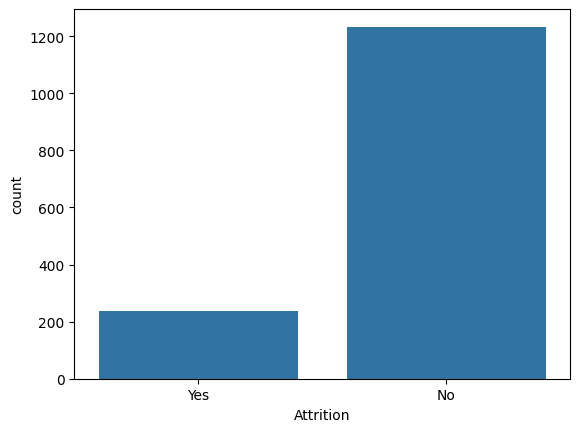

In [3]:
sns.countplot(x='Attrition', data=df)
plt.show()


##5. Data Cleaning & Preprocessing

a) Handle missing values

Check nulls:

In [4]:
df.isna().sum()


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


b) Encode categorical data
Convert categorical columns to numeric using:

- LabelEncoder for binary categories

- OneHotEncoder for multi-class

In [5]:
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])
df = pd.get_dummies(df, drop_first=True)


##6. Feature Selection

Choose relevant columns for prediction. You can drop IDs and non-influential columns.

Example features:

In [6]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']


##7. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##8. Choose & Train Model

You can start with Logistic Regression (simple, interpretable) then compare others like Random Forest.

Logistic Regression:

In [8]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Random Forest Classifier (better for complex data):

In [9]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

##9. Evaluate Model

Check performance on test data:

0.8673469387755102
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       255
           1       0.50      0.18      0.26        39

    accuracy                           0.87       294
   macro avg       0.69      0.58      0.60       294
weighted avg       0.83      0.87      0.84       294



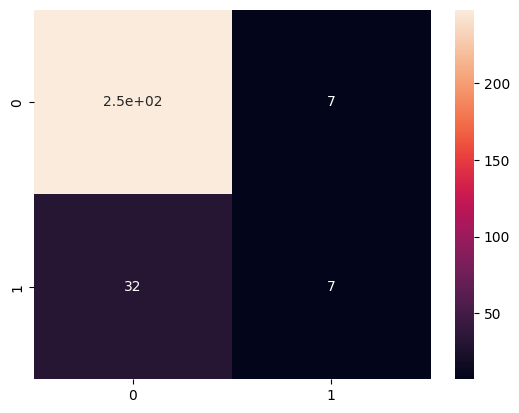

In [10]:
y_pred = lr.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()


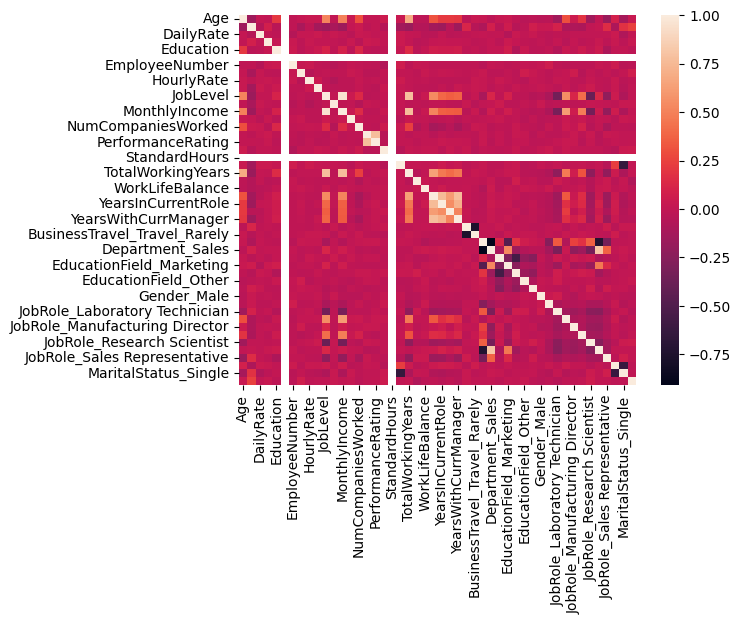

In [11]:
sns.heatmap(df.corr())
plt.show()


##STEP 1: Save Your Trained Model

In [12]:
import pickle

pickle.dump(rf, open("attrition_model.pkl", "wb"))


##STEP 2: Install Required Libraries in Colab

In [13]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 60.2 MB/s eta 0:00:00


##STEP 3: Create Streamlit App File

In [14]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load model
model = pickle.load(open("attrition_model.pkl", "rb"))

st.title("Employee Attrition Prediction Dashboard")

st.write("Enter employee details:")

age = st.number_input("Age", 18, 60)
income = st.number_input("Monthly Income", 1000, 200000)
joblevel = st.selectbox("Job Level", [1, 2, 3, 4, 5])
overtime = st.selectbox("Overtime", ["Yes", "No"])

# Encode Overtime
overtime = 1 if overtime == "Yes" else 0

if st.button("Predict Attrition"):
    input_data = np.array([[age, income, joblevel, overtime]])
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("Employee is likely to LEAVE")
    else:
        st.success("Employee is likely to STAY")


Writing app.py


##STEP 4: Run Streamlit in Colab (Expose URL)

In [16]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64


--2025-12-18 13:00:02--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64 [following]
--2025-12-18 13:00:02--  https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/955e9d1b-ac5e-4188-8867-e5f53958a8fe?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-18T13%3A53%3A24Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-1

In [17]:
!streamlit run app.py &>/content/logs.txt &


In [18]:
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501


2025-12-18T13:00:35Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-12-18T13:00:35Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-12-18T13:00:40Z INF +--------------------------------------------------------------------------------------------+
2025-12-18T13:00:40Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2025-12-18T13:00:40Z INF |  https://follows-student-ist-wives.trycloudflare.com  

In [20]:
X = pd.get_dummies(X, drop_first=True)


In [21]:
import pickle

pickle.dump(X.columns.tolist(), open("feature_names.pkl", "wb"))
pickle.dump(rf, open("attrition_model.pkl", "wb"))


In [22]:
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Load model & feature names
model = pickle.load(open("attrition_model.pkl", "rb"))
feature_names = pickle.load(open("feature_names.pkl", "rb"))

st.title("Employee Attrition Prediction Dashboard")

# User Inputs
age = st.number_input("Age", 18, 60)
income = st.number_input("Monthly Income", 1000, 200000)
joblevel = st.selectbox("Job Level", [1, 2, 3, 4, 5])
overtime = st.selectbox("Overtime", ["Yes", "No"])

# Encode inputs
input_dict = {
    "Age": age,
    "MonthlyIncome": income,
    "JobLevel": joblevel,
    "OverTime_Yes": 1 if overtime == "Yes" else 0
}

# Create empty input dataframe with all features
input_df = pd.DataFrame(0, index=[0], columns=feature_names)

# Fill known values
for key, value in input_dict.items():
    if key in input_df.columns:
        input_df[key] = value

if st.button("Predict Attrition"):
    prediction = model.predict(input_df)

    if prediction[0] == 1:
        st.error("⚠️ Employee is likely to LEAVE")
    else:
        st.success("✅ Employee is likely to STAY")


2025-12-18 13:09:43.177 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.642 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-12-18 13:09:43.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 13:09:43.656 Thread 'MainThread': mi

In [26]:
!streamlit run app.py &>/content/logs.txt &
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501


2025-12-18T13:23:41Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-12-18T13:23:41Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-12-18T13:23:46Z INF +--------------------------------------------------------------------------------------------+
2025-12-18T13:23:46Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2025-12-18T13:23:46Z INF |  https://grown-rebound-syndication-arthur.trycloudflar

In [24]:
!git config --global user.name "priashapatle"
!git config --global user.email "priashapatle@gmail.com"


In [25]:
!git clone https://github.com/priashapatle/employee-attrition-prediction.git


Cloning into 'employee-attrition-prediction'...


In [30]:
%cd employee-attrition-prediction


[Errno 2] No such file or directory: 'employee-attrition-prediction'
/content/employee-attrition-prediction


In [31]:
!pwd


/content/employee-attrition-prediction


In [33]:
!ls


In [36]:
!mv ../app.py .
!mv ../attrition_model.pkl .
!mv ../feature_names.pkl .
!mv ../*.ipynb .


mv: cannot stat '../*.ipynb': No such file or directory


In [37]:
!git add .
!git commit -m "Initial commit: Employee Attrition Prediction with Streamlit dashboard"


[main (root-commit) 0cde3ca] Initial commit: Employee Attrition Prediction with Streamlit dashboard
 3 files changed, 27 insertions(+)
 create mode 100644 app.py
 create mode 100644 attrition_model.pkl
 create mode 100644 feature_names.pkl


In [39]:
!git branch -M main
!git push origin main


fatal: could not read Username for 'https://github.com': No such device or address
